In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Generate 120 days of library energy usage
days = pd.date_range(start="2026-01-01", periods=120, freq="D")

np.random.seed(42)

base_usage = np.random.normal(120, 15, 120)

# Exam period surge in last 20 days
exam_boost = np.zeros(120)
exam_boost[-20:] = np.random.randint(30, 60, 20)

energy_usage = base_usage + exam_boost

library_data = pd.DataFrame({
    "date": days,
    "energy_usage_kwh": energy_usage
})

library_data.head()

,date,energy_usage_kwh
0,2026-01-01,127.450712
1,2026-01-02,117.926035
2,2026-01-03,129.715328
3,2026-01-04,142.845448
4,2026-01-05,116.487699


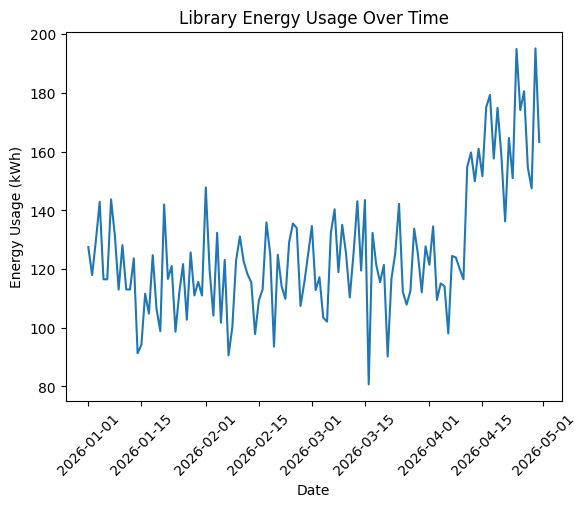

In [3]:
plt.plot(library_data["date"], library_data["energy_usage_kwh"])
plt.title("Library Energy Usage Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Usage (kWh)")
plt.xticks(rotation=45)
plt.show()

In [4]:
library_data = library_data.set_index("date")
library_data = library_data.asfreq("D")

library_data.head()

,energy_usage_kwh
date,
2026-01-01,127.450712
2026-01-02,117.926035
2026-01-03,129.715328
2026-01-04,142.845448
2026-01-05,116.487699


In [5]:
model = ExponentialSmoothing(
    library_data["energy_usage_kwh"],
    trend="add",
    seasonal=None
)

model_fit = model.fit()

print("Model trained successfully")

Model trained successfully


In [6]:
forecast = model_fit.forecast(steps=14)

forecast

2026-05-01    172.528440
2026-05-02    173.510256
2026-05-03    174.492073
2026-05-04    175.473890
2026-05-05    176.455707
2026-05-06    177.437524
2026-05-07    178.419341
2026-05-08    179.401157
2026-05-09    180.382974
2026-05-10    181.364791
2026-05-11    182.346608
2026-05-12    183.328425
2026-05-13    184.310242
2026-05-14    185.292059
Freq: D, dtype: float64

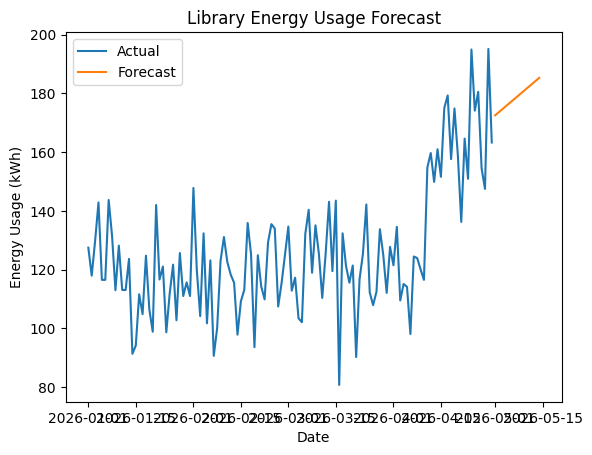

In [7]:
future_dates = pd.date_range(
    start=library_data.index[-1] + pd.Timedelta(days=1),
    periods=14,
    freq="D"
)

plt.plot(library_data.index, library_data["energy_usage_kwh"], label="Actual")
plt.plot(future_dates, forecast, label="Forecast")

plt.title("Library Energy Usage Forecast")
plt.xlabel("Date")
plt.ylabel("Energy Usage (kWh)")
plt.legend()
plt.show()

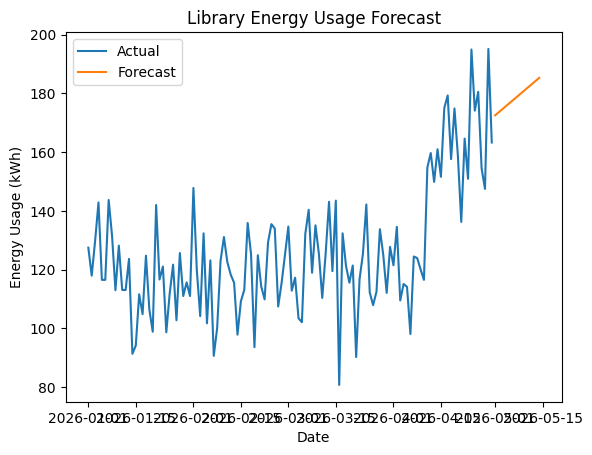

In [8]:
future_dates = pd.date_range(
    start=library_data.index[-1] + pd.Timedelta(days=1),
    periods=14,
    freq="D"
)

plt.plot(library_data.index, library_data["energy_usage_kwh"], label="Actual")
plt.plot(future_dates, forecast, label="Forecast")

plt.title("Library Energy Usage Forecast")
plt.xlabel("Date")
plt.ylabel("Energy Usage (kWh)")
plt.legend()
plt.show()

In [9]:
forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_usage": forecast.values
})

forecast_df.to_csv("../data/library_energy_forecast.csv", index=False)

forecast_df.head()

,date,predicted_usage
0,2026-05-01,172.528440
1,2026-05-02,173.510256
2,2026-05-03,174.492073
3,2026-05-04,175.473890
4,2026-05-05,176.455707


In [10]:
library_data_reset = library_data.reset_index()

library_data_reset.to_csv("../data/library_energy_usage.csv", index=False)

print("library_energy_usage.csv saved successfully")

library_energy_usage.csv saved successfully
